## 0. Introduction

The aim of this lab is to get familiar with **classification problems** and **logistic regression**. We will be using some code extracts that were implemented last week and build a logistic regression model.

1.   This lab is the second course-work activity **Assignment 1 Part 2: Classification**
2. Assignment 1 is split into 3 parts: Part 1 - Regression (Lab 3), and Part 2 - Classification (Lab 4) and Part 3 - Neural Networks (Lab 6). The three parts need to be submitted together by  **Monday, 11th November 2024, 10:00am**
3. All questions need to be completed and are assessed.
4. For each lab, a report answering the <font color = 'red'>**questions in red**</font> should be included along with the completed Notebook (.ipynb)
5. The report should be a separate file in **pdf format** (so **NOT** *doc, docx, notebook* etc.).
6. Make sure that **any figures or code** you comment on, are **included in the report**.
7. There are three parts of Assignment 1, therefore you should submit a zip file that contains 1 x Notebook and 1 x PDF for each part. In total: 3 x Notebooks and 3 x PDFs in the submission zip. Make sure the file is well identified with your name, student number, assignment number (for instance, Assignment 1), module code.
7. No other means of submission other than the appropriate QM+ link is acceptable at any time (so NO email attachments, etc.)
8. **PLAGIARISM** <ins>is an irreversible non-negotiable failure in the course</ins> (if in doubt of what constitutes plagiarism, ask!).


For this lab, we will be using the [iris dataset](https://scikit-learn.org/stable/datasets/toy_dataset.html#iris-dataset).

In [1]:
import torch
from torch import nn
from torch import optim
from torch.nn import functional as F
from sklearn import model_selection
from sklearn import datasets
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
from IPython import display

import typing
%matplotlib inline

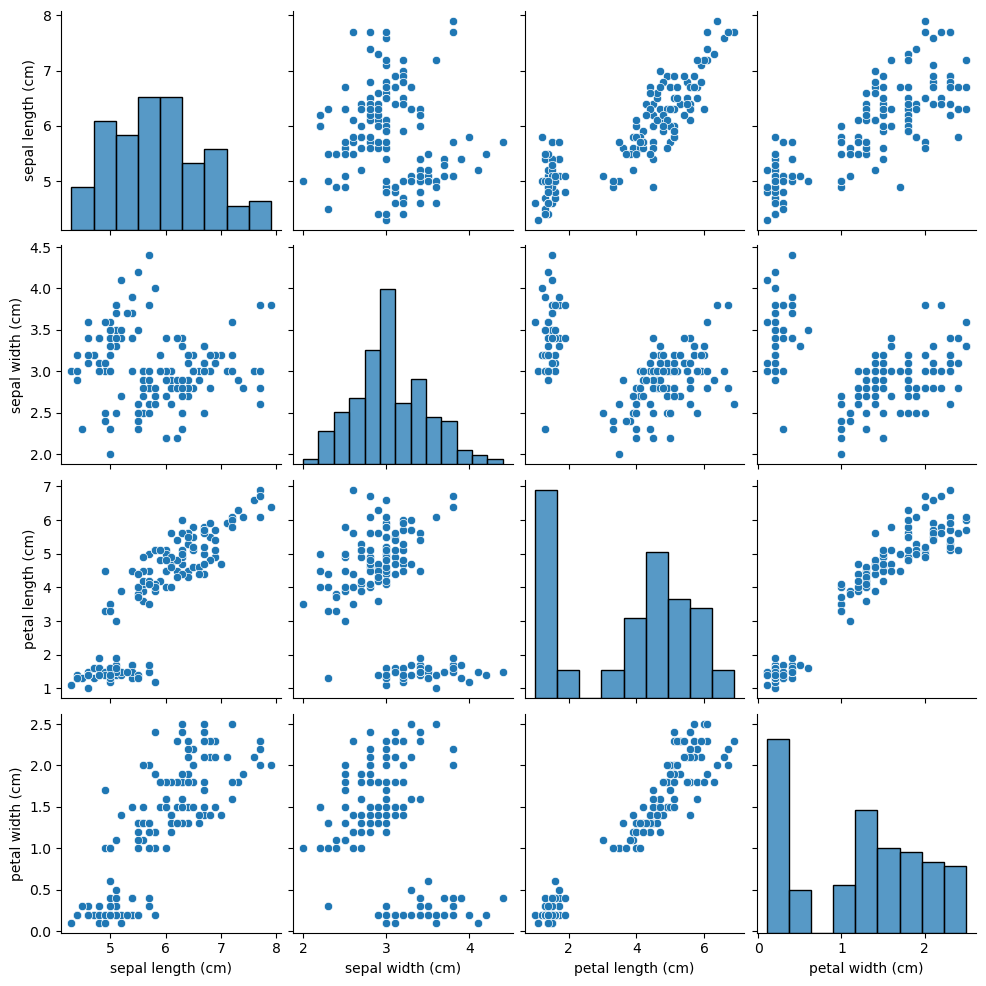

In [2]:
iris_db = datasets.load_iris(as_frame=True)
sn.pairplot(iris_db.data)

In [3]:
iris_db.data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


We will split the data into train and test sets. For consistency and to allow for meaningful comparison the same splits are maintained in the remainder of the lab.

In [4]:
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    iris_db.data,
    iris_db.target,
    test_size=0.2,
    random_state=42
    )
x_train = torch.from_numpy(X_train.values).float()
x_test = torch.from_numpy(X_test.values).float()

y_train = torch.from_numpy(y_train.values).int()
y_train = y_train.reshape(-1, 1)

y_test = torch.from_numpy(y_test.values).int()
y_test = y_test.reshape(-1, 1)

<font color="red">**Q1.** We again notice that the attributes are on different scales. Use the normalisation method from last lab, to standardize the scales of each attribute on both sets. Plot the normalized and raw training sets; what do you observe? [2 marks] </font>

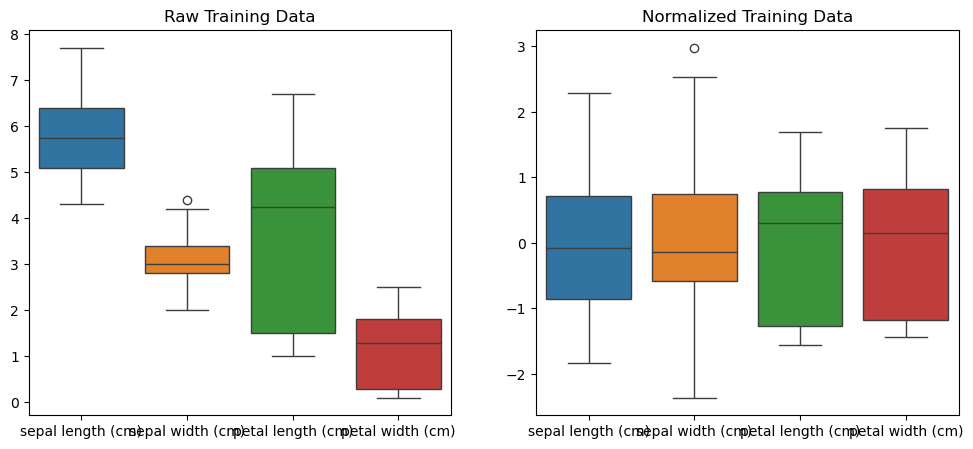

In [5]:
### your code here
#normalisation method from lab 3: 
def norm_set(x: torch.Tensor, mu: torch.Tensor, sigma: torch.Tensor) -> torch.tensor:
  z = (x - mu) / sigma #the formula for z-score normalization
  return z

# Calculate mean and std from training set
mu = x_train.mean(dim=0)
sigma = x_train.std(dim=0)

# Normalize both training and test sets
x_train_norm = norm_set(x_train, mu, sigma)
x_test_norm = norm_set(x_test, mu, sigma)

#convert norm and raw training sets to df for easier plotting
raw_df = pd.DataFrame(x_train.numpy(), columns=iris_db.feature_names)
norm_df = pd.DataFrame(x_train_norm.numpy(), columns=iris_db.feature_names)

#plot raw vs norm data
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sn.boxplot(data=raw_df)
plt.title('Raw Training Data')
plt.subplot(1, 2, 2)
sn.boxplot(data=norm_df)
plt.title('Normalized Training Data')
plt.show()

By inspecting the dataset we see that it contains 4 attributes. (`sepal length`, `sepal width`, `petal length`, `petal width`, in centimeters). For simplicity we will focus on the first two.

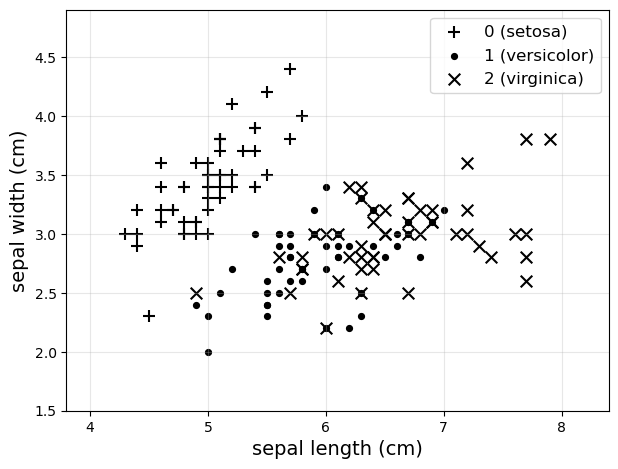

In [6]:
X = iris_db.data.iloc[:, :2]
Y = iris_db.target
marker_list = ['+', '.', 'x']
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111)
ax.set_aspect('equal')

for l in [0, 1, 2]:
  ax.scatter(
      X.loc[Y == l].iloc[:, 0],
      X.loc[Y == l].iloc[:, 1],
      marker=marker_list[l],
      s=70,
      color='black',
      label='{:d} ({:s})'.format(l, iris_db.target_names[l])
      )

ax.legend(fontsize=12)
ax.set_xlabel(iris_db.feature_names[0], fontsize=14)
ax.set_ylabel(iris_db.feature_names[1], fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(X.iloc[:, 0].min() - 0.5, X.iloc[:, 0].max() + 0.5)
ax.set_ylim(X.iloc[:, 1].min() - 0.5, X.iloc[:, 1].max() + 0.5)
plt.show()

Is the data linearly separable?

As there are multiple classes, for now we will focus on class 0 (setosa). As such, we modify the `y_train` and `y_test` tensors, so that each label is 1 if the class is setosa and 0 if otherwise.

In [7]:
train_set_1 = x_train[:, :2]
test_set_1 = x_test[:, :2]

# add a feature for bias
train_set_1 = torch.cat([train_set_1, torch.ones(train_set_1.shape[0], 1)], dim=1)
test_set_1 = torch.cat([test_set_1, torch.ones(test_set_1.shape[0], 1)], dim=1)

setosa_train = (y_train == 0).int()
setosa_test = (y_test == 0).int()

## 1. Sigmoid function
With logistic regression the values we want to predict are now discrete classes, not continuous variables. In other words, logistic regression is for classification tasks. In the binary classification problem we have classes $0$ and $1$, e.g. classifying email as spam or not spam based on words used in the email.

The logistic/sigmoid function given by the formula below:

$ h_{\theta}(x) = g(\theta^{T}x) =  \frac{1}{1+ e^{-\theta^Tx}} $

**Q2.** First implement the above function in `def sigmoid()`. [2 marks]

**Q3.** Then, using the implementation of `LinearRegression` from last week as guideline, create a custom pytorch layer for `LogisticRegression` [2 marks]

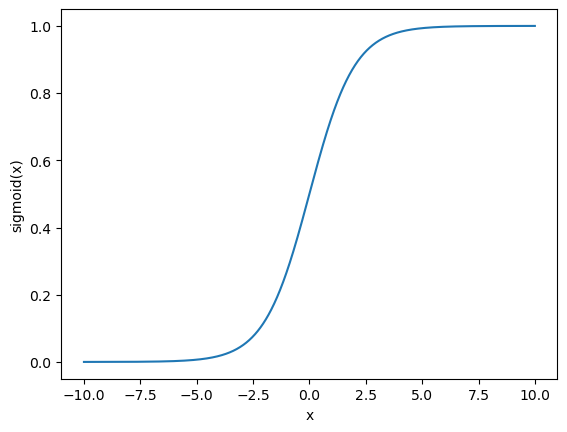

In [8]:
def sigmoid(z: torch.Tensor) -> torch.Tensor:
  ### your code here
  return 1/ (1 + torch.exp(-z))


x = torch.arange(1,2000, 1)/100.0 - 10
y = sigmoid(x)
fig, ax1 = plt.subplots()
ax1.plot(x, y)
# set label of horizontal axis
ax1.set_xlabel('x')
# set label of vertical axis
ax1.set_ylabel('sigmoid(x)')
plt.show()

In [9]:
class LogisticRegression(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.weight = nn.Parameter(torch.zeros(1, num_features), requires_grad=False)

  def forward(self, x):
    y = 0
    ### your code here
    z = x @ self.weight.t() #linear combination of inputs and weights. the forward of the linear regression class lab 3
    y = sigmoid(z) #apply signmoid
    return y

The cost function we will use for logistic regression is the **Cross Entropy Loss**, which is given by the form:

$J(\theta) = \frac{1}{m} \sum_{i=1}^m \left[ \left(- y^{(i)} log( h_{\theta}(x^{(i)})) - (1-y^{(i)})log(1-h_{\theta}(x^{(i)}))    \right) \right] $

Which when taking partial derivatives and putting these into the gradient descent update equation gives


$
 \theta_{j} =  \theta_{j} - \alpha \frac{1}{m}  \sum_{i=1}^m ( h_{\theta}(x^{(i)}) - y^{(i)})x^{(i)}_{j}
$

**Q4.** Implement the cost in `bce()` and update the `gradient_descent_step()` from last week to update using the partial derivative above. [4 marks]

In [10]:
def bce(y_true: torch.Tensor, y_pred: torch.Tensor) -> torch.Tensor:
  ### your code here
  #take care of log(0) as its undefined
  epsilon = 1e-7
  y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)
  #compute binary cross entropy loss
  bce_loss = - (y_true * torch.log(y_pred) + (1 - y_true) * torch.log(1 - y_pred))
  bce_loss = bce_loss.mean()
  return bce_loss


def gradient_descent_step(model: nn.Module, X: torch.Tensor, y: torch.Tensor, y_pred: torch.Tensor, lr: float) -> None:
  weight = model.weight
  N = X.shape[0]
  ### your code here
  grad = (1 / N) * (X.t() @ (y_pred - y))  # gradient using partial derivative
  weight -= lr * grad.t()  # update weights using gradient descent
  
  ### update model weights
  model.weight = nn.Parameter(weight, requires_grad=False)

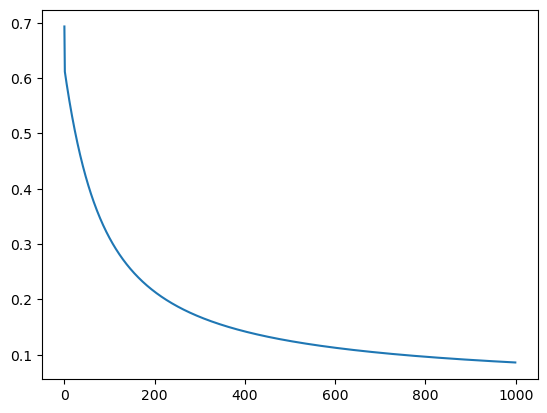

Parameter containing:
tensor([[-2.9501,  4.7836,  0.7627]])
Minimum cost: 0.08597522228956223


In [11]:
def train(model, x, y, alpha):
  cost_lst = list()
  for it in range(1000):
    prediction = model(x)
    cost = bce(y, prediction)
    cost_lst.append(cost)
    gradient_descent_step(model, x, y, prediction, alpha) #changed this as gradient descent function (mode, x, y, y_pred, lr)
  display.clear_output(wait=True)
  plt.plot(list(range(it+1)), cost_lst)
  plt.show()
  print(model.weight)
  print('Minimum cost: {}'.format(min(cost_lst)))

model = LogisticRegression(train_set_1.shape[1])
alpha = 0.1 # select an appropriate lr ## 1 too high. 0.01 too low. 0.1 best
train(model, train_set_1, setosa_train, alpha)

<font color="red"> **Q5.** Draw the decision boundary on the test set using the learned parameters. Is this decision boundary separating the classes? Does this match our expectations? [2 marks]</font>

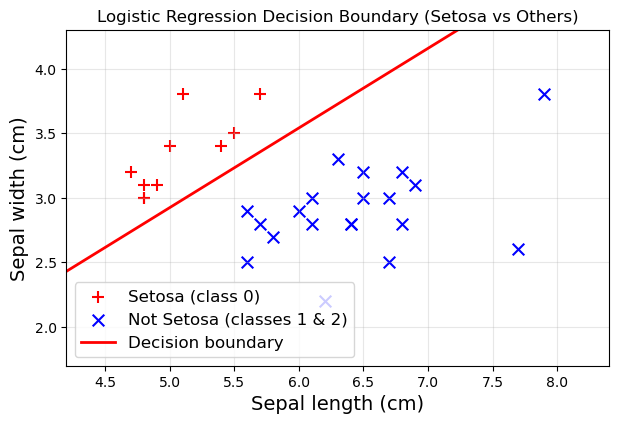

In [12]:
### your code here

#extract weights from trained model
w = model.weight.detach().numpy().flatten() # 3 numbers w0 sepal lenght, w1 sepad width, w2 bias. 

#get feature limits from the test set. smallest and largest values for sepal length and width, plus add a tiny bit 
x_min, x_max = test_set_1[:, 0].min() - 0.5, test_set_1[:, 0].max() + 0.5
y_min, y_max = test_set_1[:, 1].min() - 0.5, test_set_1[:, 1].max() + 0.5

#generate x-values and compute decision boundary line (where sigmoid function output=0.5)
x_vals = torch.linspace(x_min, x_max, 100) #to draw the decision boundary
y_vals = -(w[0] * x_vals + w[2]) / w[1] #==0 and solve it for y

#plot
fig, ax = plt.subplots(figsize=(7,7))
ax.set_aspect('equal')

# Plot the binary test points (Setosa vs Others)
ax.scatter(
    test_set_1[setosa_test[:, 0] == 1][:, 0],
    test_set_1[setosa_test[:, 0] == 1][:, 1],
    color='red',
    label='Setosa (class 0)',
    s=70,
    marker='+'
)
ax.scatter(
    test_set_1[setosa_test[:, 0] == 0][:, 0],
    test_set_1[setosa_test[:, 0] == 0][:, 1],
    color='blue',
    label='Not Setosa (classes 1 & 2)',
    s=70,
    marker='x'
)

# plot decision boundary
ax.plot(x_vals.numpy(), y_vals.numpy(), 'r-', linewidth=2, label='Decision boundary')

ax.legend(fontsize=12)
ax.set_xlabel('Sepal length (cm)', fontsize=14)
ax.set_ylabel('Sepal width (cm)', fontsize=14)
ax.grid(alpha=0.3)
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
plt.title('Logistic Regression Decision Boundary (Setosa vs Others)')
plt.show()

## 2. Multiclass
So far, we have focused on a binary classification (is this iris setosa or not), however in this section we will address the problem as a multiclass classification. We will be using a 1 vs. all approach (refer to the lecture notes for details). We will also be using all 4 attributes for the classification.

Firstly, we need to process `y_train, y_test` so that each label is a vector rather than an integer.

In [13]:
y_train = F.one_hot(y_train.reshape(-1).long(), num_classes=3)
y_test = F.one_hot(y_test.reshape(-1).long(), num_classes=3)
print(y_test.shape)

torch.Size([30, 3])


In this section we will use the built in pytorch methods.


In [14]:
alpha = 0.1
setosa_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
setosa_labels = y_train[:, 0].reshape(-1, 1).float()
setosa_testy = y_test[:, 0].reshape(-1, 1).float()
optimiser = optim.SGD(setosa_model.parameters(), alpha)

def train(model, x, y, test_x, test_y, optimiser, alpha):
  train_lst = list()
  test_lst = list()
  for i in range(1000):
    model.train()
    optimiser.zero_grad()
    pred = model(x)
    cost = F.binary_cross_entropy(pred, y, reduction='mean')
    cost.backward()
    train_lst.append(cost.item())
    optimiser.step()
    model.eval()
    with torch.no_grad():
      test_pred = model(test_x)
      test_cost = F.binary_cross_entropy(test_pred, test_y, reduction='mean')
      test_lst.append(test_cost)
  fig, axs = plt.subplots(2)
  axs[0].plot(list(range(i+1)), train_lst)
  axs[1].plot(list(range(i+1)), test_lst)
  plt.show()
  print('Minimum train cost: {}'.format(min(train_lst)))
  print('Minimum test cost: {}'.format(min(test_lst)))


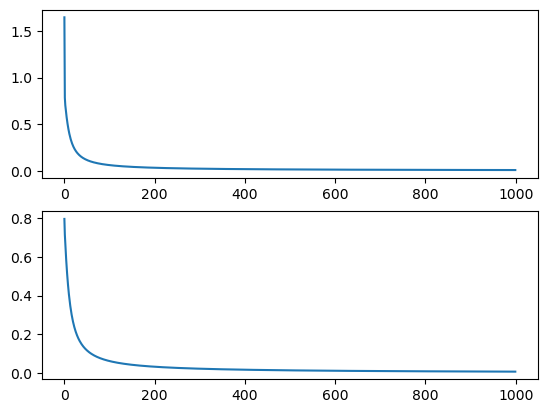

Minimum train cost: 0.007466258015483618
Minimum test cost: 0.0074395895935595036


In [15]:
train(setosa_model, x_train, setosa_labels, x_test, setosa_testy, optimiser, alpha)

How does the cost of the 4 attribute model compare to the previous one?

**Q6** Now train classifiers for the other two classes.[1 mark]

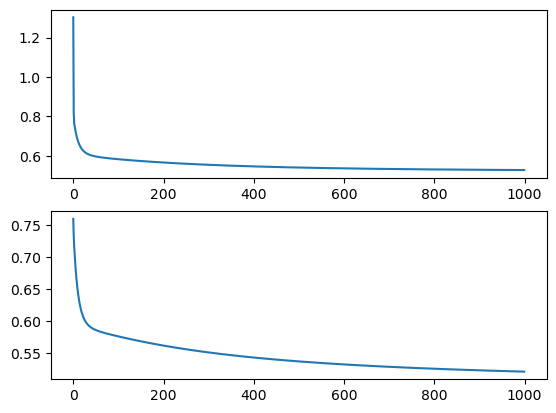

Minimum train cost: 0.5280007123947144
Minimum test cost: 0.521605908870697


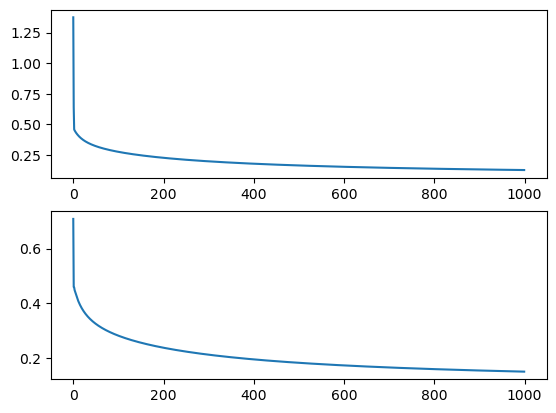

Minimum train cost: 0.12774699926376343
Minimum test cost: 0.14898355305194855


In [16]:
### your code here
#same process as the setosa model. copy and paste from before just changing the values
alpha= 0.1

#train for class 1=versicolor
versicolor_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
versicolor_labels = y_train[:, 1].reshape(-1, 1).float()
versicolor_testy = y_test[:, 1].reshape(-1, 1).float()
optimiser1 = optim.SGD(versicolor_model.parameters(), alpha)

train(versicolor_model, x_train, versicolor_labels, x_test, versicolor_testy, optimiser1, alpha)

#train for class2= virginica
virginica_model = nn.Sequential(nn.Linear(x_train.shape[1], 1, bias=False), nn.Sigmoid())
virginica_labels = y_train[:, 2].reshape(-1, 1).float()
virginica_testy = y_test[:, 2].reshape(-1, 1).float()
optimiser2 = optim.SGD(virginica_model.parameters(), alpha)

train(virginica_model, x_train, virginica_labels, x_test, virginica_testy, optimiser2, alpha)

<font color="red"> **Q7.** Using the 3 classifiers, predict the classes of the samples in the test set and show the predictions in a table. Do you observe anything interesting? [4 marks] </font>

In [17]:
### your code here
#get class prob from each ove-vs-all model
with torch.no_grad():
    p0 = setosa_model(x_test)
    p1 = versicolor_model(x_test)
    p2 = virginica_model(x_test)
    
#combine their outputs. stack probs into a single tensor
probs = torch.cat([p0, p1, p2], dim=1)

#predicted class = index of the max prob
preds = torch.argmax(probs, dim=1)

true_classes = torch.argmax(y_test, dim=1)

#build table for comparison
predictions_df = pd.DataFrame({
    "True Class": true_classes.numpy(),
    "Predicted Class": preds.numpy()
})

print(predictions_df.head(20))

    True Class  Predicted Class
0            1                1
1            0                0
2            2                2
3            1                1
4            1                1
5            0                0
6            1                1
7            2                2
8            1                1
9            1                1
10           2                2
11           0                0
12           0                0
13           0                0
14           0                0
15           1                1
16           2                2
17           1                1
18           1                1
19           2                2


<font color="red"> **Q8.** Calculate the accuracy of the classifier on the test set, by comparing the predicted values against the ground truth. Use a softmax for the classifier outputs. [1 mark] </font>

In [18]:
#with the softmax the predictions are mutually exclusive== prob sum to 1. 
with torch.no_grad():
    #get class prob from each ove-vs-all model
    p0 = setosa_model(x_test)
    p1 = versicolor_model(x_test)
    p2 = virginica_model(x_test)

    #combine their outputs. stack probs into a single tensor
    probs = torch.cat([p0, p1, p2], dim=1)

    #apply softmax across the three columns
    softmax_probs = F.softmax(probs, dim=1)

    #predicted class = index of the max prob
    preds = torch.argmax(softmax_probs, dim=1)

    #true labels
    true_classes = torch.argmax(y_test, dim=1)
    
accuracy = (preds == true_classes).float().mean()
print("Test accuracy:", accuracy.item())

Test accuracy: 1.0


## 3. The XOR problem

<font color="red"> **Q9.** Looking at the datapoints below, can we draw a decision boundary using Logistic Regression? Why? What are the specific issues or logistic regression with regards to XOR? [2 marks] </font>

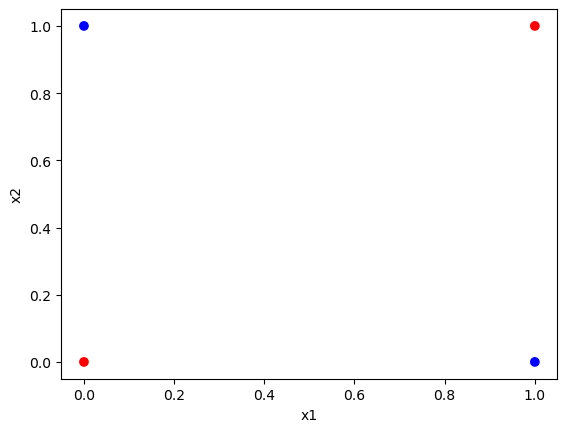

In [19]:
x1 = [0, 0, 1, 1]
x2 = [0, 1, 0, 1]
y = [0, 1, 1, 0]

c_map = ['r', 'b', 'b', 'r']
plt.scatter(x1, x2, c=c_map)
plt.xlabel('x1')
plt.ylabel('x2')
plt.show()